In [8]:
import numpy as np
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth,association_rules

   support               itemsets
0      0.8                (Bread)
1      0.6               (Butter)
2      0.6                 (Milk)
3      0.6                 (Eggs)
4      0.4        (Butter, Bread)
5      0.6         (Butter, Milk)
6      0.4          (Milk, Bread)
7      0.4  (Butter, Milk, Bread)
8      0.4          (Eggs, Bread)


In [4]:
data = {
    'Milk': [1, 1, 0, 1, 0],
    'Bread': [1, 0, 1, 1, 1],
    'Butter': [1, 1, 0, 1, 0],
    'Eggs': [0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

In [5]:
df_bool=df.astype(bool)

In [7]:
frequent_itemsets = fpgrowth(df_bool, min_support=0.4, use_colnames=True)

print(frequent_itemsets)

   support               itemsets
0      0.8                (Bread)
1      0.6               (Butter)
2      0.6                 (Milk)
3      0.6                 (Eggs)
4      0.4        (Butter, Bread)
5      0.6         (Butter, Milk)
6      0.4          (Milk, Bread)
7      0.4  (Butter, Milk, Bread)
8      0.4          (Eggs, Bread)


In [10]:
rules  = association_rules(frequent_itemsets, metric="confidence",min_threshold=0.6)

print(rules)

       antecedents      consequents  antecedent support  consequent support  \
0         (Butter)          (Bread)                 0.6                 0.8   
1         (Butter)           (Milk)                 0.6                 0.6   
2           (Milk)         (Butter)                 0.6                 0.6   
3           (Milk)          (Bread)                 0.6                 0.8   
4   (Butter, Milk)          (Bread)                 0.6                 0.8   
5  (Butter, Bread)           (Milk)                 0.4                 0.6   
6    (Milk, Bread)         (Butter)                 0.4                 0.6   
7         (Butter)    (Milk, Bread)                 0.6                 0.4   
8           (Milk)  (Butter, Bread)                 0.6                 0.4   
9           (Eggs)          (Bread)                 0.6                 0.8   

   support  confidence      lift  representativity  leverage  conviction  \
0      0.4    0.666667  0.833333               1.0    

In [12]:
from collections import defaultdict

transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Milk', 'Butter'],
    ['Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Eggs']
]

# Count frequency
freq = defaultdict(int)

for transaction in transactions:
    for item in transaction:
        freq[item] += 1

print(freq.items())

dict_items([('Milk', 3), ('Bread', 4), ('Butter', 3), ('Eggs', 2)])


In [20]:
min_support = 2

# Filter items
freq = {k: v for k, v in freq.items() if v >= min_support}

new_transactions = []

for t in transactions:
    filtered = []
    
    for item in t:
        if item in freq:
            filtered.append(item)
    
    filtered.sort(key=lambda x: freq[x], reverse=True)
    
    if filtered:   # ✅ avoid empty transactions
        new_transactions.append(filtered)

print(new_transactions)

[['Bread', 'Milk', 'Butter'], ['Milk', 'Butter'], ['Bread', 'Eggs'], ['Bread', 'Milk', 'Butter'], ['Bread', 'Eggs']]


In [18]:
freq

{'Milk': 3, 'Bread': 4, 'Butter': 3, 'Eggs': 2}

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [22]:
iris = load_iris()
X=iris.data
y=iris.target

In [24]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [25]:
pca = PCA(n_components=2)
pca_scaled = pca.fit_transform(scaled_X)

In [28]:
original_df = pd.DataFrame(data=X[:,:2],columns=(["Sepal Length","Sepal Width"]))
original_df["Species"]=y

In [29]:
original_df

,Sepal Length,Sepal Width,Species
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


In [30]:
pca_df = pd.DataFrame(data=pca_scaled,columns=(["PC1","PC2"]))
pca_df["Species"]=y

In [31]:
pca_df

,PC1,PC2,Species
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0
...,...,...,...
145,1.870503,0.386966,2
146,1.564580,-0.896687,2
147,1.521170,0.269069,2
148,1.372788,1.011254,2


In [33]:
import seaborn as sns

In [59]:
Species = iris.target_names

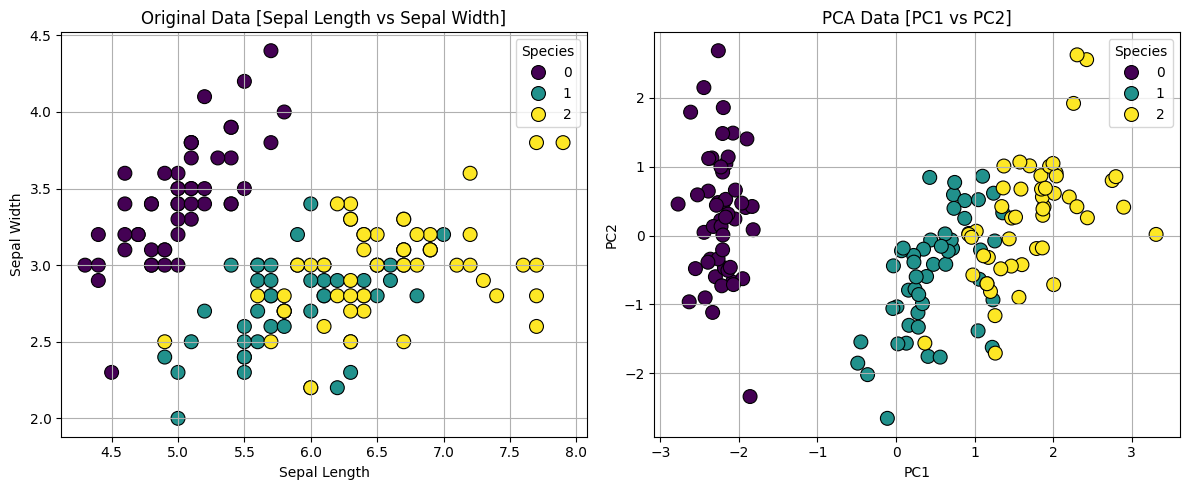

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# 🔹 Plot 1: Original Data
plt.subplot(1,2,1)
sns.scatterplot(
    data=original_df,
    x="Sepal Length",
    y="Sepal Width",
    hue="Species",
    palette="viridis",
    s=100,
    edgecolor='black'
)

plt.title('Original Data [Sepal Length vs Sepal Width]')
plt.grid()

# 🔹 Plot 2: PCA Data
plt.subplot(1,2,2)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Species",
    palette="viridis",
    s=100,
    edgecolor='black'
)

plt.title('PCA Data [PC1 vs PC2]')
plt.grid()

plt.tight_layout()
plt.show()

In [42]:
explained = pca.explained_variance_ratio_

In [43]:
print(explained)

[0.72962445 0.22850762]


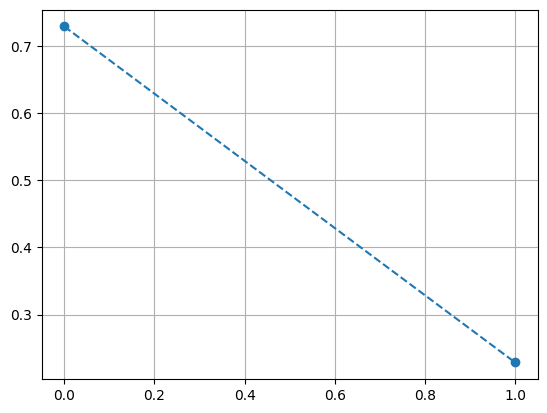

In [49]:
plt.plot(range(0,2),explained,marker="o",linestyle="--")
plt.grid(True)
plt.show()

In [50]:
from sklearn.cluster import KMeans

In [53]:
inertia = [KMeans(n_clusters=k,random_state=42,n_init=10).fit(pca_df).inertia_ for k in range(1,11)]

C:\Users\Harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Harsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

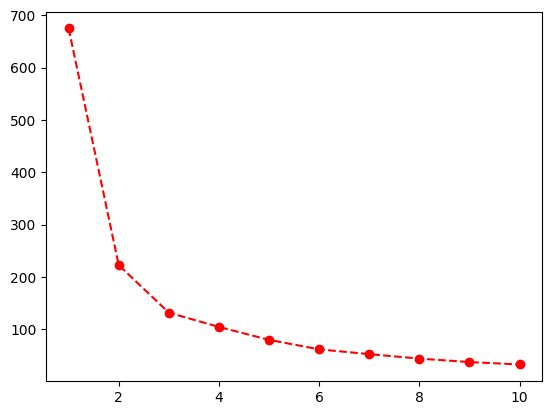

In [56]:
plt.plot(range(1,11),inertia,marker="o",color="r",linestyle="--")

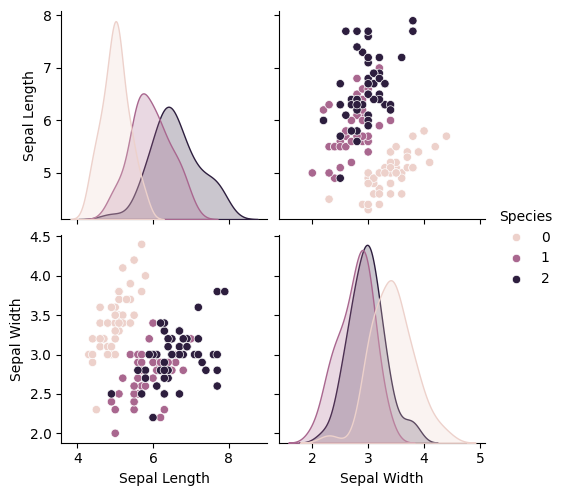

In [64]:
sns.pairplot(original_df, hue='Species')
plt.show()

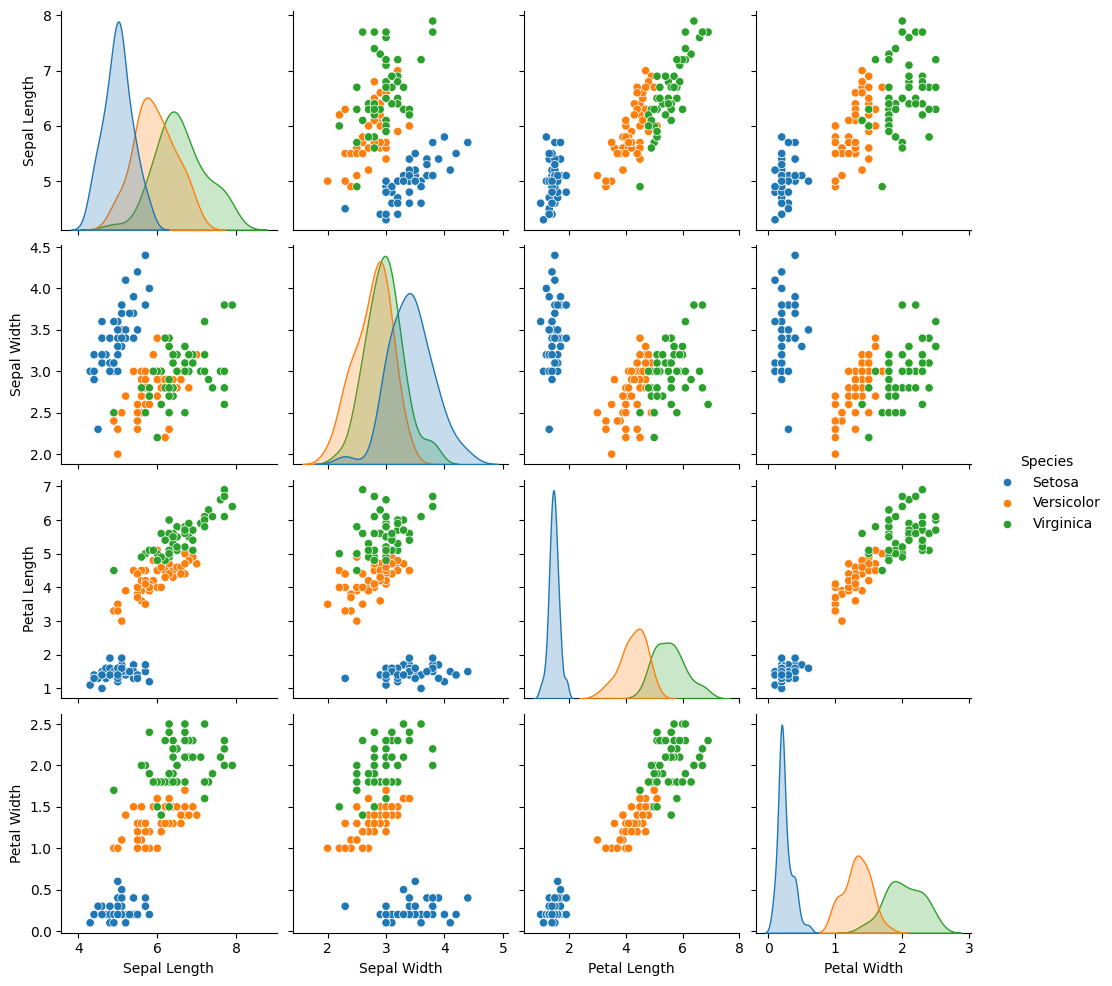

In [68]:
sns.pairplot(df, hue='Species')
plt.show()